In [250]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score


In [251]:
x = pd.read_csv("mean_x")
y = pd.read_csv("mean_y")

In [252]:
x['name'] = range(1, len(x) + 1)
y['name'] = range(1, len(y) + 1)


In [253]:
mean_df = pd.merge(x, y, how='outer', on="name", left_on=None, right_on=None, left_index=False, right_index=False)

In [254]:
mean_df

,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,ЭХС,...,НеЖК,ХЛ,ФЛ_y,ФЛ,СХ_y,СЖК,ТГ,ЭХ_y,name,здоров(1)\болен(0)
0,3.08,33.333333,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,19.000000,...,27.66,15.87,24.61,11.100000,17.510000,27.650000,22.610000,21.140000,1,0.0
1,2.05,28.205128,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,19.000000,...,20.72,12.09,34.84,14.740000,16.960000,21.820000,25.220000,21.260000,2,0.0
2,1.03,23.076923,8.000000,8.700000,65.000,7.700000,369.000000,0.283000,3.000000,15.000000,...,19.26,14.86,22.21,8.670000,13.460000,19.590000,33.530000,24.760000,3,0.0
3,1.53,38.461538,6.800000,6.000000,85.600,7.700000,328.900000,0.370714,3.000000,15.000000,...,34.26,7.48,13.97,15.560000,19.880000,29.380000,28.710000,24.360000,4,0.0
4,2.05,30.769231,6.800000,6.000000,85.600,7.700000,328.900000,0.370714,3.000000,16.000000,...,32.04,16.17,12.29,8.100000,19.400000,15.900000,30.890000,25.730000,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,1.53,25.641026,9.600000,9.300000,75.200,10.900000,222.420000,0.342000,3.800000,17.488095,...,36.40,14.52,6.57,11.380000,15.270000,23.910000,19.650000,29.790000,91,0.0
91,1.53,33.333333,10.000000,6.000000,65.000,8.900000,467.940000,0.256000,7.300000,17.488095,...,29.94,11.44,14.21,20.270000,32.100000,22.880000,14.060000,10.690000,92,0.0
92,1.03,33.333333,10.000000,6.000000,65.000,8.900000,467.940000,0.256000,7.300000,17.488095,...,35.98,11.39,7.79,12.140000,16.930000,23.380000,27.550000,19.100000,93,0.0
93,1.03,35.897436,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,17.488095,...,36.40,14.52,6.58,11.650000,18.140000,26.300000,22.310000,21.600000,94,0.0


In [255]:
import pandas as pd
import numpy as np

df = mean_df
healthy = df[df['здоров(1)\болен(0)'] == 1].copy()

categorical_cols = ['Пол', 'Форма']
target_col = 'здоров(1)\болен(0)'
numeric_cols = [c for c in healthy.columns 
                if c not in categorical_cols + [target_col]]

N_new = 65
new_people = []

# Вычисляем стандартные отклонения для шума
std_devs = healthy[numeric_cols].std()

for _ in range(N_new):
    # Случайно выбираем исходного человека
    original = healthy.sample(n=1).iloc[0]
    
    # Добавляем шум (5% от стандартного отклонения)
    noise = np.random.normal(0, std_devs * 0.05, len(numeric_cols))
    
    person = {}
    for i, col in enumerate(numeric_cols):
        person[col] = max(0, original[col] + noise[i])  # не допускаем отрицательных
        person[col] = round(person[col], 2)
    
    # Категориальные признаки копируем с вероятностью 80% (небольшой шум)
    if np.random.random() > 0.2:
        person['Пол'] = original['Пол']
        person['Форма'] = original['Форма']
    else:
        person['Пол'] = np.random.choice([1, 2])
        person['Форма'] = np.random.choice([0, 2, 3, 4])
    
    person['здоров(1)\болен(0)'] = 1
    new_people.append(person)

df_new = pd.DataFrame(new_people)
df_new.to_csv('synthetic_healthy_people.csv', index=False)

print(f"✅ Сгенерировано {N_new} человек методом бутстрапа с шумом")
print(df_new.head())

✅ Сгенерировано 65 человек методом бутстрапа с шумом
   ПОЛ в плазме  ПОЛ в мембр. Эритроцитов  Лактат  Глюкоза  Общий белок  \
0          0.83                      5.44   74.17     6.52         3.29   
1          0.84                      5.38   69.62     5.61         2.01   
2          1.21                      4.75   72.69     3.55         5.86   
3          0.85                      6.05   75.10     4.93         4.79   
4          2.02                      4.59   58.60     5.52         4.25   

   Мочевина  Кортизол  Зонулин  Холестерин    ЭХС  ...   ФЛ_y     ФЛ   СХ_y  \
0      1.53     31.10   237.83        0.22  16.13  ...   8.76  10.65  14.13   
1      2.59     33.35   342.28        0.41  13.09  ...  12.77  11.91  19.17   
2      3.03     28.01   293.78        0.28  17.61  ...  13.78   9.85  15.99   
3      2.01     23.08   235.13        0.26  17.42  ...  11.02  11.92  19.18   
4      1.56     25.42   240.64        0.62  14.22  ...  13.76  11.75  19.22   

     СЖК     ТГ   ЭХ_

In [256]:
synthetic_healthy_people = pd.read_csv("synthetic_healthy_people.csv")
synthetic_healthy_people

,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,ЭХС,...,ФЛ_y,ФЛ,СХ_y,СЖК,ТГ,ЭХ_y,name,Пол,Форма,здоров(1)\болен(0)
0,0.83,5.44,74.17,6.52,3.29,1.53,31.10,237.83,0.22,16.13,...,8.76,10.65,14.13,22.77,32.18,20.12,75.24,1.0,0.0,1
1,0.84,5.38,69.62,5.61,2.01,2.59,33.35,342.28,0.41,13.09,...,12.77,11.91,19.17,22.74,24.51,23.84,37.31,1.0,0.0,1
2,1.21,4.75,72.69,3.55,5.86,3.03,28.01,293.78,0.28,17.61,...,13.78,9.85,15.99,28.84,25.80,19.69,54.85,2.0,4.0,1
3,0.85,6.05,75.10,4.93,4.79,2.01,23.08,235.13,0.26,17.42,...,11.02,11.92,19.18,22.76,24.34,24.62,20.25,1.0,4.0,1
4,2.02,4.59,58.60,5.52,4.25,1.56,25.42,240.64,0.62,14.22,...,13.76,11.75,19.22,23.03,24.48,23.80,58.86,1.0,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1.62,6.28,84.89,5.64,6.83,1.54,20.23,193.16,0.28,12.83,...,13.09,11.94,18.93,22.73,24.62,24.03,34.52,2.0,3.0,1
61,0.80,5.97,75.13,4.99,4.85,2.03,23.55,234.98,0.27,16.82,...,11.07,11.97,19.17,22.71,24.46,23.94,21.31,1.0,2.0,1
62,2.01,5.30,74.60,5.45,3.39,1.50,30.67,235.97,0.27,13.83,...,17.20,11.86,19.19,22.71,24.47,23.95,51.40,1.0,4.0,1
63,2.03,5.29,75.21,5.49,3.32,1.47,30.44,231.43,0.28,13.85,...,17.09,11.91,19.23,22.79,24.41,23.82,52.38,2.0,4.0,1


In [257]:
synthetic_healthy_people['name'] = range(96, 96 + len(synthetic_healthy_people))
synthetic_healthy_people

,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,ЭХС,...,ФЛ_y,ФЛ,СХ_y,СЖК,ТГ,ЭХ_y,name,Пол,Форма,здоров(1)\болен(0)
0,0.83,5.44,74.17,6.52,3.29,1.53,31.10,237.83,0.22,16.13,...,8.76,10.65,14.13,22.77,32.18,20.12,96,1.0,0.0,1
1,0.84,5.38,69.62,5.61,2.01,2.59,33.35,342.28,0.41,13.09,...,12.77,11.91,19.17,22.74,24.51,23.84,97,1.0,0.0,1
2,1.21,4.75,72.69,3.55,5.86,3.03,28.01,293.78,0.28,17.61,...,13.78,9.85,15.99,28.84,25.80,19.69,98,2.0,4.0,1
3,0.85,6.05,75.10,4.93,4.79,2.01,23.08,235.13,0.26,17.42,...,11.02,11.92,19.18,22.76,24.34,24.62,99,1.0,4.0,1
4,2.02,4.59,58.60,5.52,4.25,1.56,25.42,240.64,0.62,14.22,...,13.76,11.75,19.22,23.03,24.48,23.80,100,1.0,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1.62,6.28,84.89,5.64,6.83,1.54,20.23,193.16,0.28,12.83,...,13.09,11.94,18.93,22.73,24.62,24.03,156,2.0,3.0,1
61,0.80,5.97,75.13,4.99,4.85,2.03,23.55,234.98,0.27,16.82,...,11.07,11.97,19.17,22.71,24.46,23.94,157,1.0,2.0,1
62,2.01,5.30,74.60,5.45,3.39,1.50,30.67,235.97,0.27,13.83,...,17.20,11.86,19.19,22.71,24.47,23.95,158,1.0,4.0,1
63,2.03,5.29,75.21,5.49,3.32,1.47,30.44,231.43,0.28,13.85,...,17.09,11.91,19.23,22.79,24.41,23.82,159,2.0,4.0,1


In [258]:
merge_columns = [
    "name", "ПОЛ в плазме", "ПОЛ в мембр. Эритроцитов", "Лактат", 
    "Глюкоза", "Общий белок", "Мочевина", "Кортизол", "Зонулин", 
    "Холестерин", "здоров(1)\болен(0)", "ЭХС", "ТГ_x", "НЭЖК", 
    "СХ_x", "ФЛ_x", "Пол", "Возраст", "Форма", "ЭХ_x", "ТГ_y", 
    "НеЖК", "ХЛ", "ФЛ_y", "ФЛ", "СХ_y", "СЖК", "ТГ", "ЭХ_y"
]

# Выполняем объединение
new_1_people_df = pd.merge(
    df, 
    synthetic_healthy_people, 
    how='outer', 
    on=merge_columns
)

In [259]:
new_1_people_df

,ПОЛ в плазме,ПОЛ в мембр. Эритроцитов,Лактат,Глюкоза,Общий белок,Мочевина,Кортизол,Зонулин,Холестерин,ЭХС,...,НеЖК,ХЛ,ФЛ_y,ФЛ,СХ_y,СЖК,ТГ,ЭХ_y,name,здоров(1)\болен(0)
0,3.08,33.333333,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,19.00,...,27.66,15.87,24.61,11.10,17.51,27.65,22.61,21.14,1,0.0
1,2.05,28.205128,29.622619,6.827381,39.155,7.063651,248.718361,95.402933,2.504494,19.00,...,20.72,12.09,34.84,14.74,16.96,21.82,25.22,21.26,2,0.0
2,1.03,23.076923,8.000000,8.700000,65.000,7.700000,369.000000,0.283000,3.000000,15.00,...,19.26,14.86,22.21,8.67,13.46,19.59,33.53,24.76,3,0.0
3,1.53,38.461538,6.800000,6.000000,85.600,7.700000,328.900000,0.370714,3.000000,15.00,...,34.26,7.48,13.97,15.56,19.88,29.38,28.71,24.36,4,0.0
4,2.05,30.769231,6.800000,6.000000,85.600,7.700000,328.900000,0.370714,3.000000,16.00,...,32.04,16.17,12.29,8.10,19.40,15.90,30.89,25.73,5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1.62,6.280000,84.890000,5.640000,6.830,1.540000,20.230000,193.160000,0.280000,12.83,...,21.23,12.32,13.09,11.94,18.93,22.73,24.62,24.03,156,1.0
156,0.80,5.970000,75.130000,4.990000,4.850,2.030000,23.550000,234.980000,0.270000,16.82,...,35.73,11.96,11.07,11.97,19.17,22.71,24.46,23.94,157,1.0
157,2.01,5.300000,74.600000,5.450000,3.390,1.500000,30.670000,235.970000,0.270000,13.83,...,22.66,19.91,17.20,11.86,19.19,22.71,24.47,23.95,158,1.0
158,2.03,5.290000,75.210000,5.490000,3.320,1.470000,30.440000,231.430000,0.280000,13.85,...,22.74,19.90,17.09,11.91,19.23,22.79,24.41,23.82,159,1.0


In [260]:
x = new_1_people_df.drop("здоров(1)\болен(0)",axis=1)
y = new_1_people_df["здоров(1)\болен(0)"]

In [261]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y,random_state=42)


Accuracy:0.979
Precision:1.000
Recall:  0.958
F1-score: 0.979

Confusion Matrix:
 [[24  0]
 [ 1 23]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        24
         1.0       1.00      0.96      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48

F1-результаты по фолдам: [0.         1.         0.94117647 1.         1.        ]
Средний F1: 0.79


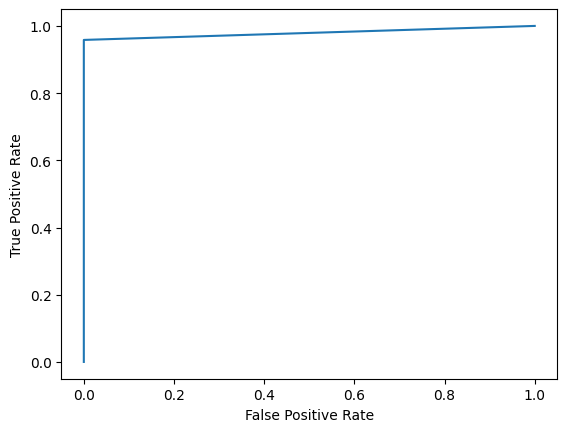

In [262]:
clf = DecisionTreeClassifier(random_state = 42,max_depth = 2)
clf.fit(x_train, y_train)
prediction = clf.predict(x_test)
accuracy_score(prediction, y_test)
print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
print(f"Precision:{precision_score(y_test, prediction):.3f}")
print(f"Recall:  {recall_score(y_test, prediction):.3f}")
print(f"F1-score: {f1_score(y_test, prediction):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))


scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

# построение ROC кривой
plt.plot(fpr, tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
from sklearn.model_selection import cross_val_score


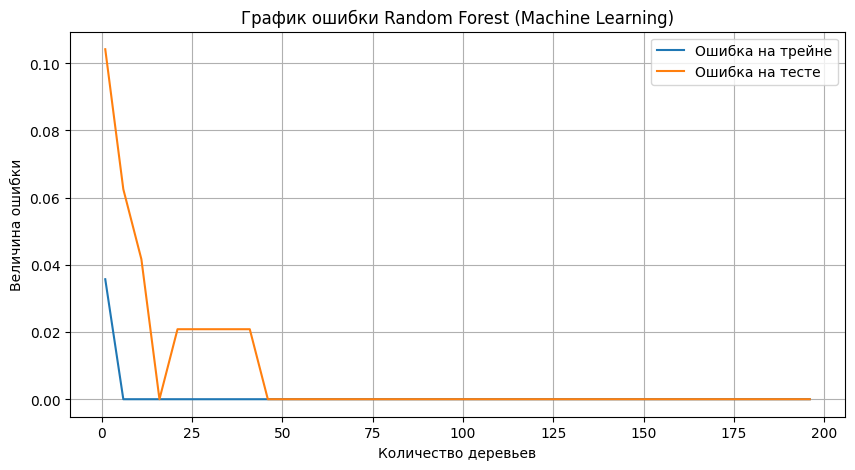

Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000

Confusion Matrix:
 [[24  0]
 [ 0 24]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        24
         1.0       1.00      1.00      1.00        24

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

F1-результаты по фолдам: [0.96774194 0.94117647 1.         0.96969697 1.        ]
Средний F1: 0.98


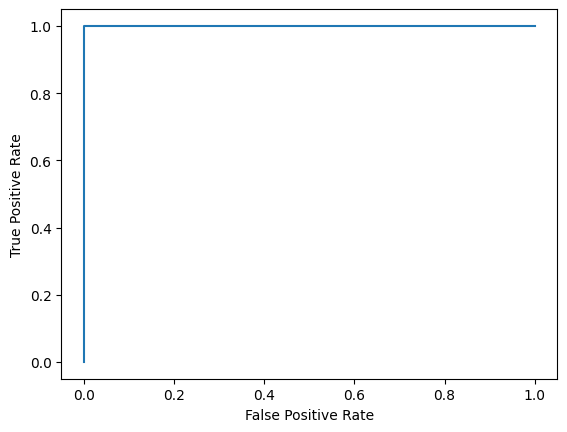

In [263]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Параметры
n_trees = 200
train_errors = []
test_errors = []

# Создаем модель с warm_start=True, чтобы дообучать, а не переобучать заново
clf_graph = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=3, warm_start=False)

# Цикл для сбора данных об ошибке (шаг 5 для скорости)
tree_steps = range(1, n_trees + 1, 5)
for i in tree_steps:
    clf_graph.set_params(n_estimators=i)
    clf_graph.fit(x_train, y_train)
    
    # Считаем ошибку (1 - Accuracy)
    train_errors.append(1 - accuracy_score(y_train, clf_graph.predict(x_train)))
    test_errors.append(1 - accuracy_score(y_test, clf_graph.predict(x_test)))

# Строим график ошибки
plt.figure(figsize=(10, 5))
plt.plot(tree_steps, train_errors, label='Ошибка на трейне')
plt.plot(tree_steps, test_errors, label='Ошибка на тесте')
plt.title('График ошибки Random Forest (Machine Learning)')
plt.xlabel('Количество деревьев')
plt.ylabel('Величина ошибки')
plt.legend()
plt.grid(True)
plt.show()


clf = RandomForestClassifier(n_estimators=200,random_state = 42,max_depth = 3)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_pred, y_test)
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

# построение ROC кривой
plt.plot(fpr, tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
from sklearn.model_selection import cross_val_score


In [266]:
new_1_people_df.to_csv("new_1_people_df.csv", index = False)

In [267]:
import joblib
joblib.dump(clf, 'saved_model/random_forest_model_with_new_1_category_people.pkl')

['saved_model/random_forest_model_with_new_1_category_people.pkl']

Accuracy:0.979
Precision:1.000
Recall:  0.958
F1-score: 0.979

Confusion Matrix:
 [[24  0]
 [ 1 23]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      1.00      0.98        24
         1.0       1.00      0.96      0.98        24

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



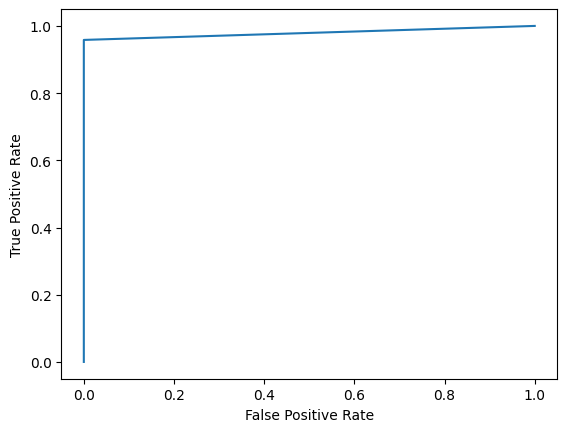

F1-результаты по фолдам: [0.         0.96969697 0.94117647 0.94117647 1.        ]
Средний F1: 0.77


In [265]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Создаем веса для каждой строки обучающей выборки
# weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
accuracy_score(y_pred, y_test)
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_pred):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

# построение ROC кривой
plt.plot(fpr, tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()
from sklearn.model_selection import cross_val_score


scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")